In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
path = "/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET"

In [3]:
files = os.listdir("/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion")
print(files)

['utils.py', 'Readme file - Description of Experimental Tests.txt', 'Technical Information and Experimental Test Results for LG 18650HG2.pdf', '10degC', '0degC', '25degC', '40degC', 'n10degC', 'n20degC']


In [4]:
!pip -q install xgboost

In [5]:
import os
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings("ignore")
print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
PROJECT_PATH = "/content/drive/MyDrive/BATTERY_SOC_PROJECT"
DAY16_PATH = os.path.join(PROJECT_PATH, "day16_outputs")
os.makedirs(DAY16_PATH, exist_ok=True)
print("Project path:", PROJECT_PATH)
print("Day 16 output path:", DAY16_PATH)
print("Project paths ready.")

Project path: /content/drive/MyDrive/BATTERY_SOC_PROJECT
Day 16 output path: /content/drive/MyDrive/BATTERY_SOC_PROJECT/day16_outputs
Project paths ready.


In [7]:
def find_file(filename):
    for root, dirs, files in os.walk(PROJECT_PATH):
        if filename in files:
            return os.path.join(root, filename)
    return None
required_files = ["SOC_train_engineered_day13.csv","SOC_validation_engineered_day13.csv","SOC_test_engineered_day13.csv","remaining_time_train_engineered_day13.csv","remaining_time_validation_engineered_day13.csv","remaining_time_test_engineered_day13.csv","final_feature_list_day13.json"]
file_paths = {}
for filename in required_files:
    path = find_file(filename)
    if path is None:
        raise FileNotFoundError(
            f"Required file not found: {filename}\n"
            f"Please check that the Day 13 files are present inside {PROJECT_PATH}")
    file_paths[filename] = path
    print(filename, "->", path)
print("All required Day 13 files found.")

SOC_train_engineered_day13.csv -> /content/drive/MyDrive/BATTERY_SOC_PROJECT/day13_feature_engineering/SOC_train_engineered_day13.csv
SOC_validation_engineered_day13.csv -> /content/drive/MyDrive/BATTERY_SOC_PROJECT/day13_feature_engineering/SOC_validation_engineered_day13.csv
SOC_test_engineered_day13.csv -> /content/drive/MyDrive/BATTERY_SOC_PROJECT/day13_feature_engineering/SOC_test_engineered_day13.csv
remaining_time_train_engineered_day13.csv -> /content/drive/MyDrive/BATTERY_SOC_PROJECT/day13_feature_engineering/remaining_time_train_engineered_day13.csv
remaining_time_validation_engineered_day13.csv -> /content/drive/MyDrive/BATTERY_SOC_PROJECT/day13_feature_engineering/remaining_time_validation_engineered_day13.csv
remaining_time_test_engineered_day13.csv -> /content/drive/MyDrive/BATTERY_SOC_PROJECT/day13_feature_engineering/remaining_time_test_engineered_day13.csv
final_feature_list_day13.json -> /content/drive/MyDrive/BATTERY_SOC_PROJECT/day13_feature_engineering/final_featur

In [8]:
feature_file = file_paths["final_feature_list_day13.json"]
with open(feature_file, "r") as f:
    feature_data = json.load(f)
print("JSON content type:", type(feature_data).__name__)
print("JSON content:", feature_data)
FEATURES = []
if isinstance(feature_data, list):
    FEATURES = feature_data
elif isinstance(feature_data, dict):
    possible_keys = ["features","final_features","selected_features","feature_list","Final Features","Selected Features"]
    for key in possible_keys:
        if key in feature_data:
            value = feature_data[key]
            if isinstance(value, list):
                FEATURES = value
                break
    if not FEATURES:
        for value in feature_data.values():
            if isinstance(value, list):
                string_values = [
                    x for x in value
                    if isinstance(x, str)]
                if string_values:
                    FEATURES = string_values
                    break
FEATURES = list(dict.fromkeys(FEATURES))
if not FEATURES:
    raise ValueError(
        "Could not automatically read the Day 13 feature list. "
        "The JSON structure needs to be checked.")
print("\nFinal Day 13 features:")
for feature in FEATURES:
    print("-", feature)
print("\nNumber of features:", len(FEATURES))
print(" Day 13 feature list loaded successfully.")

JSON content type: dict
JSON content: {'SOC': ['Voltage', 'Current', 'Temperature', 'Elapsed Time', 'Cycle', 'WhAccu', 'Power'], 'Remaining Charging Time': ['Voltage', 'Current', 'Temperature', 'Elapsed Time', 'Cycle', 'Capacity', 'WhAccu', 'Power']}

Final Day 13 features:
- Voltage
- Current
- Temperature
- Elapsed Time
- Cycle
- WhAccu
- Power

Number of features: 7
 Day 13 feature list loaded successfully.


In [9]:
soc_train = pd.read_csv(file_paths["SOC_train_engineered_day13.csv"])
soc_val = pd.read_csv(file_paths["SOC_validation_engineered_day13.csv"])
soc_test = pd.read_csv(file_paths["SOC_test_engineered_day13.csv"])
time_train = pd.read_csv(file_paths["remaining_time_train_engineered_day13.csv"])
time_val = pd.read_csv(file_paths["remaining_time_validation_engineered_day13.csv"])
time_test = pd.read_csv(file_paths["remaining_time_test_engineered_day13.csv"])
print("SOC train shape:", soc_train.shape)
print("SOC validation shape:", soc_val.shape)
print("SOC test shape:", soc_test.shape)
print("Remaining Time train shape:", time_train.shape)
print("Remaining Time validation shape:", time_val.shape)
print("Remaining Time test shape:", time_test.shape)
print(" Day 13 frozen datasets loaded.")

SOC train shape: (9926, 10)
SOC validation shape: (7376, 10)
SOC test shape: (2250, 10)
Remaining Time train shape: (41015, 11)
Remaining Time validation shape: (1349, 11)
Remaining Time test shape: (2286, 11)
 Day 13 frozen datasets loaded.


In [10]:
SOC_TARGET = "SOC"
missing_features = [
    feature for feature in FEATURES
    if feature not in soc_train.columns
]
if missing_features:
    raise ValueError(f"Missing SOC features: {missing_features}")
if SOC_TARGET not in soc_train.columns:
    raise ValueError("SOC target column not found.")
X_soc_train = soc_train[FEATURES].copy()
X_soc_val = soc_val[FEATURES].copy()
X_soc_test = soc_test[FEATURES].copy()
y_soc_train = soc_train[SOC_TARGET].copy()
y_soc_val = soc_val[SOC_TARGET].copy()
y_soc_test = soc_test[SOC_TARGET].copy()
X_soc_train = X_soc_train.apply(pd.to_numeric, errors="coerce")
X_soc_val = X_soc_val.apply(pd.to_numeric, errors="coerce")
X_soc_test = X_soc_test.apply(pd.to_numeric, errors="coerce")
soc_medians = X_soc_train.median()
X_soc_train = X_soc_train.fillna(soc_medians)
X_soc_val = X_soc_val.fillna(soc_medians)
X_soc_test = X_soc_test.fillna(soc_medians)
print("SOC training samples:", len(X_soc_train))
print("SOC validation samples:", len(X_soc_val))
print("SOC test samples:", len(X_soc_test))
print("SOC data prepared using the Day 13 frozen split.")

SOC training samples: 9926
SOC validation samples: 7376
SOC test samples: 2250
SOC data prepared using the Day 13 frozen split.


In [11]:
TIME_TARGET = "Remaining Charging Time"
missing_features = [
    feature for feature in FEATURES
    if feature not in time_train.columns
]
if missing_features:
    raise ValueError(
        f"Missing Remaining Time features: {missing_features}"
    )
if TIME_TARGET not in time_train.columns:
    raise ValueError("Remaining Charging Time target column not found.")
X_time_train = time_train[FEATURES].copy()
X_time_val = time_val[FEATURES].copy()
X_time_test = time_test[FEATURES].copy()
y_time_train = time_train[TIME_TARGET].copy()
y_time_val = time_val[TIME_TARGET].copy()
y_time_test = time_test[TIME_TARGET].copy()
X_time_train = X_time_train.apply(pd.to_numeric, errors="coerce")
X_time_val = X_time_val.apply(pd.to_numeric, errors="coerce")
X_time_test = X_time_test.apply(pd.to_numeric, errors="coerce")
time_medians = X_time_train.median()
X_time_train = X_time_train.fillna(time_medians)
X_time_val = X_time_val.fillna(time_medians)
X_time_test = X_time_test.fillna(time_medians)
print("Remaining Time training samples:", len(X_time_train))
print("Remaining Time validation samples:", len(X_time_val))
print("Remaining Time test samples:", len(X_time_test))
print(" Remaining Charging Time data prepared.")

Remaining Time training samples: 41015
Remaining Time validation samples: 1349
Remaining Time test samples: 2286
 Remaining Charging Time data prepared.


In [12]:
rf_params = {"n_estimators": 200,"max_depth": 15,"min_samples_split": 5,"min_samples_leaf": 2,"random_state": 42,"n_jobs": -1}
print("Random Forest parameters:")
print(json.dumps(rf_params, indent=4))
print(" Random Forest parameters defined.")

Random Forest parameters:
{
    "n_estimators": 200,
    "max_depth": 15,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    "random_state": 42,
    "n_jobs": -1
}
 Random Forest parameters defined.


In [13]:
xgb_params = {"n_estimators": 300,"max_depth": 6,"learning_rate": 0.05,"subsample": 0.8,"colsample_bytree": 0.8,"min_child_weight": 2,"reg_alpha": 0.0,"reg_lambda": 1.0,"objective": "reg:squarederror","random_state": 42,"n_jobs": -1}
print("XGBoost parameters:")
print(json.dumps(xgb_params, indent=4))
print("XGBoost parameters defined.")

XGBoost parameters:
{
    "n_estimators": 300,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 2,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1
}
XGBoost parameters defined.


In [14]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2
def evaluate_model(model,X_train,y_train,X_val,y_val,X_test,y_test, model_name,target_name):
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)
    train_mae, train_rmse, train_r2 = calculate_metrics(y_train, train_pred)
    val_mae, val_rmse, val_r2 = calculate_metrics(y_val, val_pred)
    test_mae, test_rmse, test_r2 = calculate_metrics(y_test, test_pred)
    results = [
        {"Target": target_name,"Model": model_name,"Dataset":"Train","MAE": train_mae,"RMSE": train_rmse,"R2": train_r2 },
        {"Target": target_name, "Model": model_name,"Dataset":"Validation","MAE": val_mae,"RMSE": val_rmse,"R2": val_r2},
        {"Target": target_name,"Model": model_name,"Dataset":"Test","MAE": test_mae,"RMSE": test_rmse,"R2": test_r2}
    ]
    return results, test_pred
print("Evaluation function ready.")

Evaluation function ready.


In [15]:
rf_soc = RandomForestRegressor(**rf_params)
rf_soc.fit(X_soc_train,y_soc_train)
rf_soc_results, rf_soc_test_pred = evaluate_model(rf_soc,X_soc_train,y_soc_train,X_soc_val,y_soc_val,X_soc_test,y_soc_test,"Random Forest","SOC")
print("Random Forest SOC training completed.")

Random Forest SOC training completed.


In [16]:
rf_time = RandomForestRegressor(**rf_params)
rf_time.fit(X_time_train,y_time_train)
rf_time_results, rf_time_test_pred = evaluate_model(rf_time,X_time_train,y_time_train,X_time_val,y_time_val,X_time_test,y_time_test,"Random Forest","Remaining Charging Time")
print("Random Forest Remaining Charging Time training completed.")

Random Forest Remaining Charging Time training completed.


In [17]:
xgb_soc = XGBRegressor(**xgb_params)
xgb_soc.fit(X_soc_train,y_soc_train,verbose=False)
xgb_soc_results, xgb_soc_test_pred = evaluate_model(xgb_soc,X_soc_train,y_soc_train,X_soc_val,y_soc_val,X_soc_test,y_soc_test,"XGBoost","SOC")
print("XGBoost SOC training completed.")

XGBoost SOC training completed.


In [18]:
xgb_time = XGBRegressor(**xgb_params)
xgb_time.fit(X_time_train,y_time_train,verbose=False)
xgb_time_results, xgb_time_test_pred = evaluate_model(xgb_time,X_time_train,y_time_train, X_time_val,y_time_val,X_time_test, y_time_test,"XGBoost","Remaining Charging Time")
print("XGBoost Remaining Charging Time training completed.")

XGBoost Remaining Charging Time training completed.


In [19]:
all_day16_results = (rf_soc_results+ rf_time_results+ xgb_soc_results+ xgb_time_results)
day16_results_df = pd.DataFrame(all_day16_results)
day16_results_path = os.path.join(DAY16_PATH,"day16_ensemble_results.csv")
day16_results_df.to_csv(day16_results_path,index=False)
print("\nDay 16 model results:")
print(day16_results_df.to_string(index=False))
print("Random Forest and XGBoost results recorded.")


Day 16 model results:
                 Target         Model    Dataset        MAE        RMSE       R2
                    SOC Random Forest      Train   0.065915    0.390178 0.999914
                    SOC Random Forest Validation   9.699773   11.995793 0.778223
                    SOC Random Forest       Test   0.623971    3.769013 0.991644
Remaining Charging Time Random Forest      Train   7.252786  148.245057 0.999873
Remaining Charging Time Random Forest Validation  16.067372   25.540693 0.999687
Remaining Charging Time Random Forest       Test 481.613841  761.562992 0.998872
                    SOC       XGBoost      Train   0.100622    0.242174 0.999967
                    SOC       XGBoost Validation  10.687767   13.516056 0.718448
                    SOC       XGBoost       Test   0.500706    1.690871 0.998318
Remaining Charging Time       XGBoost      Train  21.898682   61.802548 0.999978
Remaining Charging Time       XGBoost Validation  22.567052   33.384039 0.999465
Remai

In [20]:
baseline_path = find_file("day15_baseline_results.csv")
comparison_df = day16_results_df.copy()
if baseline_path is not None:
    baseline_df = pd.read_csv(baseline_path)
    if "Model" in baseline_df.columns:
        baseline_df["Model"] = "Linear Regression"
    comparison_df = pd.concat([ baseline_df,comparison_df],ignore_index=True)
    print("Day 15 Linear Regression baseline loaded.")
else:
    print("Warning: Day 15 baseline results were not found.Only Day 16 models will be included.")
comparison_path = os.path.join(DAY16_PATH,"day16_model_comparison_results.csv")
comparison_df.to_csv(comparison_path,index=False)
print("Day 15 baseline compared with Day 16 models.")

Day 15 Linear Regression baseline loaded.
Day 15 baseline compared with Day 16 models.


In [ ]:
print("SOC TEST PREDICTIONS")
print("Saved file:")
print(soc_predictions_path)
soc_saved_predictions = pd.read_csv(soc_predictions_path)
display(soc_saved_predictions.head(20))
print("\nTotal SOC test predictions:", len(soc_saved_predictions))
print("REMAINING CHARGING TIME TEST PREDICTIONS")
print("Saved file:")
print(time_predictions_path)
time_saved_predictions = pd.read_csv(time_predictions_path)
display(time_saved_predictions.head(20))
print("\nTotal Remaining Time test predictions:",len(time_saved_predictions))
print("\nSaved test prediction tables displayed.")

SOC TEST PREDICTIONS
Saved file:
/content/drive/MyDrive/BATTERY_SOC_PROJECT/day16_outputs/SOC_ensemble_test_predictions.csv


,Actual_SOC,Random_Forest_Predicted_SOC,XGBoost_Predicted_SOC
0,2.108060,2.112591,2.159633
1,4.215699,4.217025,4.250941
2,6.324181,6.327827,6.253422
3,8.431819,8.447920,8.371970
4,10.539458,10.565937,10.557975
5,12.647518,12.714987,12.798700
6,14.755156,14.733957,15.005194
7,16.863217,16.851332,16.501200
8,18.971277,18.943143,18.894472
9,21.079337,21.041588,21.137215



Total SOC test predictions: 2250
REMAINING CHARGING TIME TEST PREDICTIONS
Saved file:
/content/drive/MyDrive/BATTERY_SOC_PROJECT/day16_outputs/Remaining_Time_ensemble_test_predictions.csv


,Actual_Remaining_Charging_Time,Random_Forest_Predicted,XGBoost_Predicted
0,245.0,322.652715,385.61490
1,185.0,213.682356,435.33096
2,125.0,154.602460,326.19748
3,65.0,112.051271,328.91806
4,5.0,11.247669,262.27072
5,0.0,12.473681,244.28104
6,4790.0,4789.226540,4773.99270
7,4730.0,4728.882540,4774.31500
8,4670.0,4674.941598,4705.21500
9,4610.0,4612.789479,4620.92400



Total Remaining Time test predictions: 2286

Saved test prediction tables displayed.


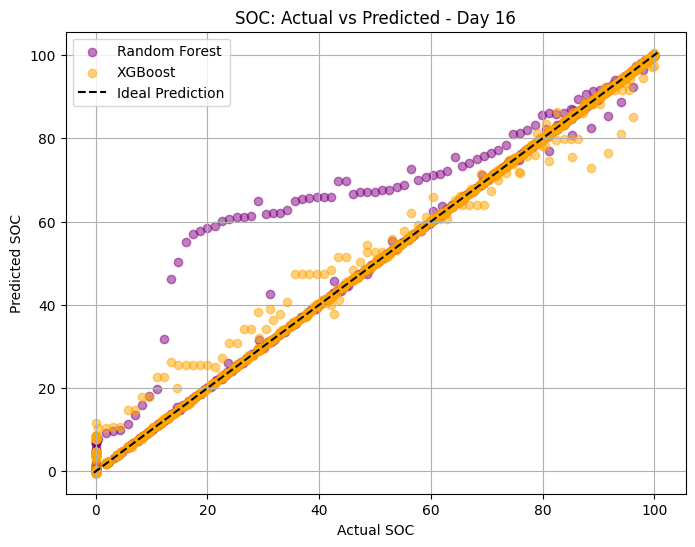

 SOC prediction plot saved.


In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(y_soc_test,rf_soc_test_pred,alpha=0.5,color="purple",label="Random Forest")
plt.scatter(y_soc_test,xgb_soc_test_pred,alpha=0.5,color="orange",label="XGBoost")
min_value = min(y_soc_test.min(),rf_soc_test_pred.min(),xgb_soc_test_pred.min())
max_value = max(y_soc_test.max(),rf_soc_test_pred.max(),xgb_soc_test_pred.max())
plt.plot([min_value, max_value],[min_value, max_value],color="black",linestyle="--",label="Ideal Prediction")
plt.xlabel("Actual SOC")
plt.ylabel("Predicted SOC")
plt.title("SOC: Actual vs Predicted - Day 16")
plt.legend()
plt.grid(True)
soc_plot_path = os.path.join(DAY16_PATH,"SOC_actual_vs_predicted_day16.png")
plt.savefig(soc_plot_path,dpi=300,bbox_inches="tight")
plt.show()
print(" SOC prediction plot saved.")

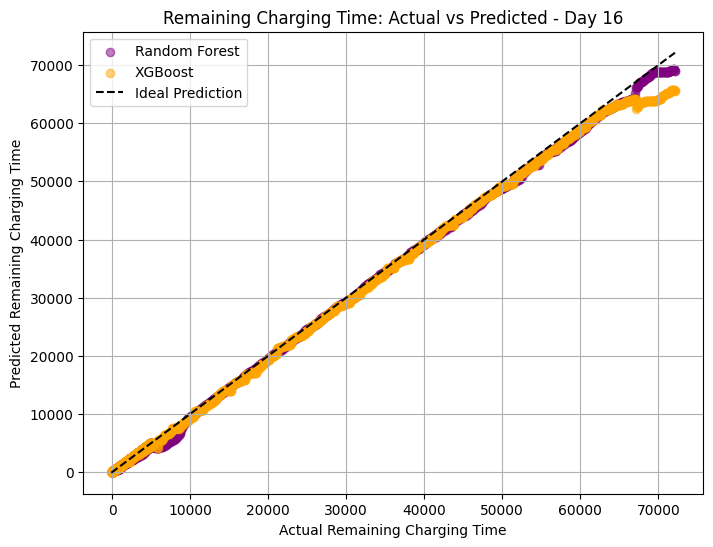

Remaining Time prediction plot saved.


In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(y_time_test,rf_time_test_pred,alpha=0.5,color="purple",label="Random Forest")
plt.scatter(y_time_test,xgb_time_test_pred,alpha=0.5,color="orange",label="XGBoost")
min_value = min(y_time_test.min(),rf_time_test_pred.min(),xgb_time_test_pred.min())
max_value = max(y_time_test.max(),rf_time_test_pred.max(),xgb_time_test_pred.max())
plt.plot([min_value, max_value],[min_value, max_value],color="black",linestyle="--",label="Ideal Prediction")
plt.xlabel("Actual Remaining Charging Time")
plt.ylabel("Predicted Remaining Charging Time")
plt.title("Remaining Charging Time: Actual vs Predicted - Day 16")
plt.legend()
plt.grid(True)
time_plot_path = os.path.join(DAY16_PATH,"Remaining_Time_actual_vs_predicted_day16.png")
plt.savefig(time_plot_path,dpi=300,bbox_inches="tight")
plt.show()
print("Remaining Time prediction plot saved.")

In [23]:
overfitting_records = []
for _, row in day16_results_df[day16_results_df["Dataset"] == "Train"].iterrows():
    target = row["Target"]
    model_name = row["Model"]
    val_row = day16_results_df[
        (day16_results_df["Target"] == target)
        &
        (day16_results_df["Model"] == model_name)
        &
        (day16_results_df["Dataset"] == "Validation")
    ]
    if len(val_row) == 0:
        continue
    train_r2 = row["R2"]
    val_r2 = val_row.iloc[0]["R2"]
    r2_gap = train_r2 - val_r2
    if r2_gap > 0.15:
        status = "Possible overfitting"
    elif train_r2 < 0.50 and val_r2 < 0.50:
        status = "Possible underfitting"
    else:
        status = "No strong overfitting/underfitting indication"
    overfitting_records.append({"Target": target,"Model": model_name,"Train_R2": train_r2,"Validation_R2": val_r2,"R2_Gap": r2_gap,"Status": status})
overfitting_df = pd.DataFrame(overfitting_records)
overfitting_path = os.path.join(DAY16_PATH,"day16_overfitting_check.csv")
overfitting_df.to_csv(overfitting_path,index=False)
print("\nOverfitting / underfitting check:")
print(overfitting_df.to_string(index=False))
print(" Overfitting/underfitting check recorded.")


Overfitting / underfitting check:
                 Target         Model  Train_R2  Validation_R2   R2_Gap                                        Status
                    SOC Random Forest  0.999914       0.778223 0.221691                          Possible overfitting
Remaining Charging Time Random Forest  0.999873       0.999687 0.000187 No strong overfitting/underfitting indication
                    SOC       XGBoost  0.999967       0.718448 0.281519                          Possible overfitting
Remaining Charging Time       XGBoost  0.999978       0.999465 0.000513 No strong overfitting/underfitting indication
 Overfitting/underfitting check recorded.


In [24]:
print("RETRAINING MODELS WITH REDUCED COMPLEXITY")
rf_tuned_params = {"n_estimators": 250,"max_depth": 8,"min_samples_split": 10,"min_samples_leaf": 4,"random_state": 42,"n_jobs": -1}
xgb_tuned_params = {"n_estimators": 300,"max_depth": 3,"learning_rate": 0.03,"subsample": 0.8,"colsample_bytree": 0.8,"min_child_weight": 4,"reg_alpha": 0.1,"reg_lambda": 5.0,"objective": "reg:squarederror","random_state": 42,"n_jobs": -1}
rf_soc_tuned = RandomForestRegressor(**rf_tuned_params)
rf_soc_tuned.fit(X_soc_train,y_soc_train)
rf_time_tuned = RandomForestRegressor(**rf_tuned_params)
rf_time_tuned.fit(X_time_train,y_time_train)
xgb_soc_tuned = XGBRegressor(**xgb_tuned_params)
xgb_soc_tuned.fit(X_soc_train,y_soc_train,verbose=False)
xgb_time_tuned = XGBRegressor(**xgb_tuned_params)
xgb_time_tuned.fit(X_time_train,y_time_train,verbose=False)
rf_soc_tuned_results, rf_soc_tuned_test_pred = evaluate_model(rf_soc_tuned,X_soc_train,y_soc_train,X_soc_val,y_soc_val,X_soc_test,y_soc_test,"Random Forest Tuned","SOC")
rf_time_tuned_results, rf_time_tuned_test_pred = evaluate_model(rf_time_tuned,X_time_train,y_time_train,X_time_val,y_time_val,X_time_test,y_time_test,"Random Forest Tuned","Remaining Charging Time")
xgb_soc_tuned_results, xgb_soc_tuned_test_pred = evaluate_model(xgb_soc_tuned,X_soc_train,y_soc_train,X_soc_val,y_soc_val,X_soc_test, y_soc_test,"XGBoost Tuned","SOC")
xgb_time_tuned_results, xgb_time_tuned_test_pred = evaluate_model(xgb_time_tuned,X_time_train,y_time_train,X_time_val,y_time_val,X_time_test,y_time_test,"XGBoost Tuned","Remaining Charging Time")
tuned_results_df = pd.DataFrame(rf_soc_tuned_results+ rf_time_tuned_results+ xgb_soc_tuned_results+ xgb_time_tuned_results)
tuned_results_path = os.path.join(DAY16_PATH,"day16_tuned_model_results.csv")
tuned_results_df.to_csv(tuned_results_path,index=False)
print("\nTUNED MODEL RESULTS")
display(tuned_results_df)
print("\nSaved to:")
print(tuned_results_path)
print("\n Models tuned and retrained.")

RETRAINING MODELS WITH REDUCED COMPLEXITY

TUNED MODEL RESULTS


,Target,Model,Dataset,MAE,RMSE,R2
0,SOC,Random Forest Tuned,Train,0.258875,0.874641,0.999567
1,SOC,Random Forest Tuned,Validation,9.072035,11.613402,0.792137
2,SOC,Random Forest Tuned,Test,0.753528,4.014321,0.990521
3,Remaining Charging Time,Random Forest Tuned,Train,54.619269,259.753224,0.999612
4,Remaining Charging Time,Random Forest Tuned,Validation,66.009018,85.341677,0.996502
5,Remaining Charging Time,Random Forest Tuned,Test,542.106640,799.685272,0.998756
6,SOC,XGBoost Tuned,Train,0.503184,1.330074,0.998999
7,SOC,XGBoost Tuned,Validation,7.498428,9.944824,0.847576
8,SOC,XGBoost Tuned,Test,1.047517,3.691105,0.991986
9,Remaining Charging Time,XGBoost Tuned,Train,129.596153,396.701981,0.999094



Saved to:
/content/drive/MyDrive/BATTERY_SOC_PROJECT/day16_outputs/day16_tuned_model_results.csv

 Models tuned and retrained.


In [25]:
print("FINAL OVERFITTING CHECK AFTER MODEL TUNING")
all_tuned_results = pd.DataFrame(rf_soc_tuned_results+ rf_time_tuned_results+ xgb_soc_tuned_results+ xgb_time_tuned_results)
final_overfitting_results = []
for (target, model), group in all_tuned_results.groupby(["Target", "Model"]):
    train_row = group[group["Dataset"] == "Train"]
    val_row = group[group["Dataset"] == "Validation"]
    if len(train_row) == 0 or len(val_row) == 0:
        continue
    train_r2 = float(train_row["R2"].iloc[0])
    val_r2 = float(val_row["R2"].iloc[0])
    gap = train_r2 - val_r2
    if gap > 0.15:
        status = "Possible Overfitting"
    elif train_r2 < 0.50 and val_r2 < 0.50:
        status = "Possible Underfitting"
    else:
        status = "No Strong Overfitting Indication"
    final_overfitting_results.append({"Target": target,"Model": model,"Train_R2": train_r2,"Validation_R2": val_r2,"R2_Gap": gap,"Status": status})
final_overfitting_df = pd.DataFrame(final_overfitting_results)
print("\nFINAL OVERFITTING CHECK:")
display(final_overfitting_df)
final_overfitting_path = os.path.join(DAY16_PATH,"day16_final_overfitting_check.csv")
final_overfitting_df.to_csv(final_overfitting_path,index=False)
print("\nSaved to:")
print(final_overfitting_path)

FINAL OVERFITTING CHECK AFTER MODEL TUNING

FINAL OVERFITTING CHECK:


,Target,Model,Train_R2,Validation_R2,R2_Gap,Status
0,Remaining Charging Time,Random Forest Tuned,0.999612,0.996502,0.003110,No Strong Overfitting Indication
1,Remaining Charging Time,XGBoost Tuned,0.999094,0.951900,0.047194,No Strong Overfitting Indication
2,SOC,Random Forest Tuned,0.999567,0.792137,0.207431,Possible Overfitting
3,SOC,XGBoost Tuned,0.998999,0.847576,0.151424,Possible Overfitting



Saved to:
/content/drive/MyDrive/BATTERY_SOC_PROJECT/day16_outputs/day16_final_overfitting_check.csv


In [26]:
model_parameters = {"Random Forest": rf_params,"XGBoost": xgb_params}
parameters_path = os.path.join(DAY16_PATH,"day16_model_parameters.json")
with open(parameters_path, "w") as f:
    json.dump(
        model_parameters,
        f,
        indent=4
    )
print("Model parameters saved.")

Model parameters saved.


In [27]:
joblib.dump(rf_soc,os.path.join(DAY16_PATH,"RandomForest_SOC_day16.joblib"))
joblib.dump(rf_time,os.path.join(DAY16_PATH,"RandomForest_Remaining_Time_day16.joblib"))
joblib.dump(xgb_soc,os.path.join( DAY16_PATH,"XGBoost_SOC_day16.joblib"))
joblib.dump(xgb_time,os.path.join(DAY16_PATH,"XGBoost_Remaining_Time_day16.joblib"))
print(" Random Forest and XGBoost model artifacts saved.")

 Random Forest and XGBoost model artifacts saved.


In [28]:
feature_info = {"day": 16,"features_used": FEATURES,"number_of_features": len(FEATURES),"soc_target": SOC_TARGET,"remaining_time_target": TIME_TARGET,"split_source": "Day 13 frozen train/validation/test split","random_state": 42}
feature_path = os.path.join(DAY16_PATH,"day16_feature_information.json")
with open(feature_path, "w") as f:
    json.dump(
        feature_info,
        f,
        indent=4
    )
print("FINAL FEATURE LIST USED FOR DAY 16")
for i, feature in enumerate(FEATURES, start=1):
    print(f"{i}. {feature}")
print("\nTotal number of features:", len(FEATURES))
print("\nSOC target:")
print("-", SOC_TARGET)
print("\nRemaining Charging Time target:")
print("-", TIME_TARGET)
print("\nSaved feature information:")
print(feature_path)
print("\nFeature list displayed and saved.")

FINAL FEATURE LIST USED FOR DAY 16
1. Voltage
2. Current
3. Temperature
4. Elapsed Time
5. Cycle
6. WhAccu
7. Power

Total number of features: 7

SOC target:
- SOC

Remaining Charging Time target:
- Remaining Charging Time

Saved feature information:
/content/drive/MyDrive/BATTERY_SOC_PROJECT/day16_outputs/day16_feature_information.json

Feature list displayed and saved.


In [29]:
findings_lines = [
    "DAY 16 INITIAL FINDINGS",
    "",
    "Models trained:",
    "1. Random Forest Regressor",
    "2. XGBoost Regressor","",
    "Targets:",
    "1. SOC",
    "2. Remaining Charging Time","",
    "The same Day 13 frozen train/validation/test split was used.",
    "No new data split was created.","",
    "Model performance was evaluated using:",
    "- MAE",
    "- RMSE",
    "- R2", "",
    "Random Forest and XGBoost were compared with the Day 15",
    "Linear Regression baseline.","",
    "Final modelling direction should be selected based on",
    "validation/test performance and overfitting behaviour."
]
findings_path = os.path.join(DAY16_PATH,"day16_initial_findings.txt")
with open(findings_path, "w") as f:
    f.write("\n".join(findings_lines))
print("Initial findings saved.")

Initial findings saved.


In [30]:
test_comparison = comparison_df[comparison_df["Dataset"].str.lower() == "test"].copy()
print("DAY 16 TEST SET MODEL COMPARISON")
print(test_comparison[["Target", "Model", "MAE", "RMSE", "R2"]].to_string(index=False))

DAY 16 TEST SET MODEL COMPARISON
                 Target         Model         MAE         RMSE       R2
                    SOC           NaN    4.681095    11.754876 0.918719
Remaining Charging Time           NaN 8817.875379 12224.276890 0.709272
                    SOC Random Forest    0.623971     3.769013 0.991644
Remaining Charging Time Random Forest  481.613841   761.562992 0.998872
                    SOC       XGBoost    0.500706     1.690871 0.998318
Remaining Charging Time       XGBoost  606.707679  1223.355192 0.997088


In [31]:
print("\nDAY 16 OUTPUT FILES:")
for filename in sorted(os.listdir(DAY16_PATH)):
    print("-", filename)
print("Random Forest: TRAINED")
print("XGBoost: TRAINED")
print("SOC predictions: GENERATED")
print("Remaining Charging Time predictions: GENERATED")
print("MAE: CALCULATED")
print("RMSE: CALCULATED")
print("R2: CALCULATED")
print("Baseline comparison: COMPLETED")
print("Prediction plots: CREATED")
print("Overfitting check: COMPLETED")
print("Model parameters: SAVED")
print("Model artifacts: SAVED")


DAY 16 OUTPUT FILES:
- RandomForest_Remaining_Time_day16.joblib
- RandomForest_SOC_day16.joblib
- Remaining_Time_actual_vs_predicted_day16.png
- Remaining_Time_ensemble_test_predictions.csv
- SOC_actual_vs_predicted_day16.png
- SOC_ensemble_test_predictions.csv
- XGBoost_Remaining_Time_day16.joblib
- XGBoost_SOC_day16.joblib
- day16_ensemble_results.csv
- day16_feature_information.json
- day16_final_overfitting_check.csv
- day16_initial_findings.txt
- day16_model_comparison_results.csv
- day16_model_parameters.json
- day16_overfitting_check.csv
- day16_tuned_model_results.csv
Random Forest: TRAINED
XGBoost: TRAINED
SOC predictions: GENERATED
Remaining Charging Time predictions: GENERATED
MAE: CALCULATED
RMSE: CALCULATED
R2: CALCULATED
Baseline comparison: COMPLETED
Prediction plots: CREATED
Overfitting check: COMPLETED
Model parameters: SAVED
Model artifacts: SAVED
